In [160]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우
plt.rcParams['axes.unicode_minus'] = False     # 마이너스 깨짐 방지

In [161]:
"""
setup_data.py - 데이터 압축 해제 스크립트
Mac에서 만든 zip의 한글 파일명도 정상 처리
"""
import zipfile
from pathlib import Path
import shutil
import sys
import os
def extract_with_encoding(zip_path, target):
    """Mac에서 만든 zip의 한글 파일명 깨짐 문제 해결"""
    with zipfile.ZipFile(zip_path, 'r') as z:
        for info in z.infolist():
            # __MACOSX 폴더 스킵
            if info.filename.startswith('__MACOSX'):
                continue
            
            # 파일명 인코딩 복구 시도 (cp437 → utf-8)
            try:
                filename = info.filename.encode('cp437').decode('utf-8')
            except (UnicodeDecodeError, UnicodeEncodeError):
                filename = info.filename
            
            # 디렉토리면 생성만
            if info.is_dir():
                (target / filename).mkdir(parents=True, exist_ok=True)
                continue
            
            # 파일 저장
            out_path = target / filename
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with z.open(info) as src, open(out_path, 'wb') as dst:
                shutil.copyfileobj(src, dst)

def main():
    BASE_DIR = Path(os.getcwd()).parent   
    RAW_DIR = BASE_DIR / 'data' / 'raw'              # ✅
    EXTRACT_DIR = BASE_DIR / 'data' / 'extracted'
    
    if not RAW_DIR.exists():
        print(f'❌ {RAW_DIR} 폴더가 없습니다.')
        sys.exit(1)
    
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    
    zip_files = sorted(RAW_DIR.glob('*.zip'))
    if not zip_files:
        print(f'⚠️  {RAW_DIR} 에 zip 파일이 없습니다.')
        sys.exit(1)
    
    print(f'📦 {len(zip_files)}개 zip 파일 처리 시작\n')
    
    extracted = 0
    skipped = 0
    
    for zip_path in zip_files:
        target = EXTRACT_DIR / zip_path.stem
        
        if target.exists() and any(target.iterdir()):
            print(f'  ⏭  {zip_path.name} (이미 풀림)')
            skipped += 1
            continue
        
        print(f'  📂 {zip_path.name}')
        target.mkdir(exist_ok=True)
        try:
            extract_with_encoding(zip_path, target)
            csv_count = len(list(target.glob('*.csv')))
            print(f'      ✅ CSV {csv_count}개 생성')
            extracted += 1
        except Exception as e:
            print(f'      ❌ 에러: {e}')
    
    print(f'\n{"="*50}')
    print(f'✅ 완료: 새로 해제 {extracted}개, 스킵 {skipped}개')
    print(f'📁 데이터 위치: {EXTRACT_DIR.resolve()}')

if __name__ == '__main__':
    main()

📦 6개 zip 파일 처리 시작

  ⏭  상권분석서비스(점포_상권).zip (이미 풀림)
  ⏭  서울시 상권분석서비스(길단위인구-상권).zip (이미 풀림)
  ⏭  서울시 상권분석서비스(상권변화지표-상권).zip (이미 풀림)
  ⏭  서울시 상권분석서비스(상주인구-상권).zip (이미 풀림)
  ⏭  서울시 상권분석서비스(직장인구-상권).zip (이미 풀림)
  ⏭  서울시_상권분석서비스(추정매출+영역).zip (이미 풀림)

✅ 완료: 새로 해제 0개, 스킵 6개
📁 데이터 위치: C:\final\seouldf\data\extracted


In [162]:
from pathlib import Path
import os

BASE_DIR = Path(os.getcwd()).parent
target_dir = BASE_DIR / 'data' / 'extracted' / '서울시_상권분석서비스(추정매출+영역)'

print("찾는 폴더:", target_dir)
print("폴더 존재 여부:", target_dir.exists())

sales_files = sorted(target_dir.glob('*.csv'))
print("파일 수:", len(sales_files))
for f in sales_files:
    print(" ", f.name)

찾는 폴더: c:\final\seouldf\data\extracted\서울시_상권분석서비스(추정매출+영역)
폴더 존재 여부: True
파일 수: 7
  서울시 상권분석서비스(영역-상권).csv
  서울시_상권분석서비스(추정매출-상권)_2020년.csv
  서울시_상권분석서비스(추정매출-상권)_2021년.csv
  서울시_상권분석서비스(추정매출-상권)_2022년.csv
  서울시_상권분석서비스(추정매출-상권)_2023년.csv
  서울시_상권분석서비스(추정매출-상권)_2024년.csv
  서울시_상권분석서비스(추정매출-상권)_2025년.csv


In [163]:
from pathlib import Path
import os
import pandas as pd

BASE_DIR = Path(os.getcwd()).parent
target_dir = BASE_DIR / 'data' / 'extracted' / '서울시_상권분석서비스(추정매출+영역)'

# 추정매출 파일만 (영역 파일 제외)
sales_files = sorted(target_dir.glob('서울시_상권분석서비스(추정매출-상권)_*.csv'))

print(f"파일 수: {len(sales_files)}")

sales_list = []
for path in sales_files:
    df = pd.read_csv(path, encoding='cp949', low_memory=False)
    sales_list.append(df)
    print(f"  ✅ {path.name} → {len(df):,}행")

sales = pd.concat(sales_list, ignore_index=True)
print(f'\n📦 통합 완료: {len(sales):,}행 × {len(sales.columns)}컬럼')
print(f'메모리: {sales.memory_usage(deep=True).sum()/1024**2:.1f} MB')

파일 수: 6
  ✅ 서울시_상권분석서비스(추정매출-상권)_2020년.csv → 80,790행
  ✅ 서울시_상권분석서비스(추정매출-상권)_2021년.csv → 89,150행
  ✅ 서울시_상권분석서비스(추정매출-상권)_2022년.csv → 88,834행
  ✅ 서울시_상권분석서비스(추정매출-상권)_2023년.csv → 88,246행
  ✅ 서울시_상권분석서비스(추정매출-상권)_2024년.csv → 87,179행
  ✅ 서울시_상권분석서비스(추정매출-상권)_2025년.csv → 85,732행

📦 통합 완료: 519,931행 × 55컬럼
메모리: 365.0 MB


In [164]:
# 데이터 모양과 타입
# print(f'추정매출: {sales.shape}')

# key_cols = ['기준_년분기_코드','상권_구분_코드_명','상권_코드','상권_코드_명',
#             '서비스_업종_코드','서비스_업종_코드_명','당월_매출_금액','당월_매출_건수']
# print(sales[key_cols].dtypes)

In [165]:
from pathlib import Path
import pandas as pd

current = Path.cwd()
project_root = current if (current / 'data').exists() else current.parent

# ✅ 길단위 데이터
csv_path1 = project_root / 'data' / '05_길단위인구' / '서울시 상권분석서비스(길단위인구-상권).csv'
df_pop = pd.read_csv(csv_path1, encoding='cp949')
print(f'길단위데이터: {df_pop.shape}')

# ✅ 소득소비 데이터
csv_path2 = project_root / 'data' / '11_소득소비' / '서울시 상권분석서비스(소득소비-상권).csv'
df_income = pd.read_csv(csv_path2, encoding='cp949')
print(f'소득소비 데이터: {df_income.shape}')

길단위데이터: (46184, 27)
소득소비 데이터: (45590, 17)


In [166]:
# JOIN_KEY = ['상권_코드', '기준_년분기_코드']

# # 1단계: 추정매출 전처리 (업종 집계)
# sales_agg = sales.groupby(JOIN_KEY).agg(
#     총매출금액=('당월_매출_금액', 'sum'),
#     총매출건수=('당월_매출_건수', 'sum'),
# ).reset_index()


# # 2단계: 시간 범위 확인 (소득소비는 갱신 중단이므로)
# print("소득소비 기간:", df_income['기준_년분기_코드'].unique())
# print("길인구 기간:",   df_pop['기준_년분기_코드'].unique())
# print("추정매출 기간:", sales['기준_년분기_코드'].unique())
# # 3단계: 3개 JOIN
# df_merged = (df_income
#     .merge(df_pop,       on=JOIN_KEY, how='inner', suffixes=('_소득', '_인구'))
#     .merge(sales_agg, on=JOIN_KEY, how='inner')
# )

# print(df_merged.shape)
# print(df_merged.columns.tolist())

In [167]:
df_pop.columns

Index(['기준_년분기_코드', '상권_구분_코드', '상권_구분_코드_명', '상권_코드', '상권_코드_명', '총_유동인구_수',
       '남성_유동인구_수', '여성_유동인구_수', '연령대_10_유동인구_수', '연령대_20_유동인구_수',
       '연령대_30_유동인구_수', '연령대_40_유동인구_수', '연령대_50_유동인구_수', '연령대_60_이상_유동인구_수',
       '시간대_00_06_유동인구_수', '시간대_06_11_유동인구_수', '시간대_11_14_유동인구_수',
       '시간대_14_17_유동인구_수', '시간대_17_21_유동인구_수', '시간대_21_24_유동인구_수',
       '월요일_유동인구_수', '화요일_유동인구_수', '수요일_유동인구_수', '목요일_유동인구_수', '금요일_유동인구_수',
       '토요일_유동인구_수', '일요일_유동인구_수'],
      dtype='str')

In [168]:
# ── 연도 컬럼 추가
df_pop['연도']    = df_pop['기준_년분기_코드'].astype(str).str[:4].astype(int)
df_income['연도'] = df_income['기준_년분기_코드'].astype(str).str[:4].astype(int)
sales['연도']     = sales['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 주중 유동인구 따로 계산
df_pop['주중_유동인구_수'] = (
    df_pop['월요일_유동인구_수'] + df_pop['화요일_유동인구_수'] +
    df_pop['수요일_유동인구_수'] + df_pop['목요일_유동인구_수'] +
    df_pop['금요일_유동인구_수']
)

df_pop['주말_유동인구_수'] = (
    df_pop['토요일_유동인구_수'] + df_pop['일요일_유동인구_수']
)

GROUP_KEY = ['연도', '상권_코드', '상권_구분_코드_명']

# ── 길단위인구: 분기 평균
df_유동_집계 = df_pop.groupby(GROUP_KEY).agg(
    총_유동인구         = ('총_유동인구_수',              'mean'),
    남성_유동인구       = ('남성_유동인구_수',             'mean'),
    여성_유동인구       = ('여성_유동인구_수',             'mean'),
    연령10_유동인구     = ('연령대_10_유동인구_수',        'mean'),
    연령20_유동인구     = ('연령대_20_유동인구_수',        'mean'),
    연령30_유동인구     = ('연령대_30_유동인구_수',        'mean'),
    연령40_유동인구     = ('연령대_40_유동인구_수',        'mean'),
    연령50_유동인구     = ('연령대_50_유동인구_수',        'mean'),
    연령60이상_유동인구 = ('연령대_60_이상_유동인구_수',   'mean'),
    시간대_심야_유동인구 = ('시간대_00_06_유동인구_수',   'mean'),
    시간대_아침_유동인구 = ('시간대_06_11_유동인구_수',   'mean'),
    시간대_점심_유동인구 = ('시간대_11_14_유동인구_수',   'mean'),
    시간대_오후_유동인구 = ('시간대_14_17_유동인구_수',   'mean'),
    시간대_저녁_유동인구 = ('시간대_17_21_유동인구_수',   'mean'),
    시간대_밤_유동인구   = ('시간대_21_24_유동인구_수',   'mean'),
    주중_유동인구       = ('주중_유동인구_수', 'mean'), 
    주말_유동인구        = ('주말_유동인구_수',          'mean'),
).reset_index()

# ── 소득소비: 분기 평균
df_소득_집계 = df_income.groupby(GROUP_KEY).agg(
    월평균소득   = ('월_평균_소득_금액',    'mean'),
    지출총금액   = ('지출_총금액',          'mean'),
    식료품지출   = ('식료품_지출_총금액',    'mean'),
    의류신발지출 = ('의류_신발_지출_총금액', 'mean'),
    생활용품지출 = ('생활용품_지출_총금액',  'mean'),
    의료비지출   = ('의료비_지출_총금액',    'mean'),
    교통지출     = ('교통_지출_총금액',      'mean'),
    여가지출     = ('여가_지출_총금액',      'mean'),
    문화지출     = ('문화_지출_총금액',      'mean'),
    교육지출     = ('교육_지출_총금액',      'mean'),
    유흥지출     = ('유흥_지출_총금액',      'mean'),
).reset_index()

# ── 매출: 업종 합산 (상권 단위로)
df_매출_집계 = sales.groupby(GROUP_KEY).agg(
    당월_매출       = ('당월_매출_금액',         'sum'),
    당월_매출건수   = ('당월_매출_건수',         'sum'),
    주중_매출       = ('주중_매출_금액',         'sum'),
    주말_매출       = ('주말_매출_금액',         'sum'),
    새벽_매출       = ('시간대_00~06_매출_금액', 'sum'),
    오전_매출       = ('시간대_06~11_매출_금액', 'sum'),
    점심_매출       = ('시간대_11~14_매출_금액', 'sum'),
    오후_매출       = ('시간대_14~17_매출_금액', 'sum'),
    저녁_매출       = ('시간대_17~21_매출_금액', 'sum'),
    심야_매출       = ('시간대_21~24_매출_금액', 'sum'),
    남성_매출       = ('남성_매출_금액',         'sum'),
    여성_매출       = ('여성_매출_금액',         'sum'),
    연령20_매출     = ('연령대_20_매출_금액',    'sum'),
    연령30_매출     = ('연령대_30_매출_금액',    'sum'),
    연령40_매출     = ('연령대_40_매출_금액',    'sum'),
    연령50_매출     = ('연령대_50_매출_금액',    'sum'),
    연령60이상_매출 = ('연령대_60_이상_매출_금액','sum'),
).reset_index()

print(f'유동인구 집계: {df_유동_집계.shape}')
print(f'소득소비 집계: {df_소득_집계.shape}')
print(f'매출 집계:     {df_매출_집계.shape}')

# ── JOIN
df_merge = (df_유동_집계
    .merge(df_소득_집계, on=GROUP_KEY, how='inner')
    .merge(df_매출_집계, on=GROUP_KEY, how='inner')
)

print(f'\n최종: {df_merge.shape}')
print(df_merge.head())

유동인구 집계: (11549, 20)
소득소비 집계: (11401, 14)
매출 집계:     (9464, 20)

최종: (9355, 48)
     연도    상권_코드 상권_구분_코드_명      총_유동인구     남성_유동인구     여성_유동인구  연령10_유동인구  \
0  2020  3001491       관광특구  1788592.25   923949.50   864642.50   95551.25   
1  2020  3001492       관광특구  6208642.00  3128195.75  3080446.00  144402.75   
2  2020  3001493       관광특구  3189657.75  1561495.50  1628162.00  117547.00   
3  2020  3001494       관광특구  8331618.50  4636799.50  3694818.75  242561.75   
4  2020  3001495       관광특구  3477993.25  1695192.00  1782801.00  306030.75   

    연령20_유동인구   연령30_유동인구   연령40_유동인구  ...         오후_매출         저녁_매출  \
0   450766.00   431544.00   282756.50  ...   63657452353   87394778249   
1  1091498.50  1572834.25  1372532.75  ...  279720774118  269891733722   
2   614093.75   810795.00   626612.00  ...   88832826912   88502995871   
3  1460409.00  1600074.50  1550396.75  ...  279926576910  150117290785   
4   775995.75   810339.25   564361.50  ...  203302374239  282754904954   

      

In [169]:
df_merge = df_merge[df_merge['연도'] < 20250]

In [170]:
df_merge.isnull().sum()

연도               0
상권_코드            0
상권_구분_코드_명       0
총_유동인구           0
남성_유동인구          0
여성_유동인구          0
연령10_유동인구        0
연령20_유동인구        0
연령30_유동인구        0
연령40_유동인구        0
연령50_유동인구        0
연령60이상_유동인구      0
시간대_심야_유동인구      0
시간대_아침_유동인구      0
시간대_점심_유동인구      0
시간대_오후_유동인구      0
시간대_저녁_유동인구      0
시간대_밤_유동인구       0
주중_유동인구          0
주말_유동인구          0
월평균소득           32
지출총금액          176
식료품지출          176
의류신발지출         176
생활용품지출         176
의료비지출          176
교통지출           176
여가지출           176
문화지출           176
교육지출           176
유흥지출           176
당월_매출            0
당월_매출건수          0
주중_매출            0
주말_매출            0
새벽_매출            0
오전_매출            0
점심_매출            0
오후_매출            0
저녁_매출            0
심야_매출            0
남성_매출            0
여성_매출            0
연령20_매출          0
연령30_매출          0
연령40_매출          0
연령50_매출          0
연령60이상_매출        0
dtype: int64

In [171]:
# 어떤 상권/연도에서 결측치가 발생하는지 먼저 확인
null_rows = df_merge[df_merge['지출총금액'].isnull()]
print(null_rows[['연도', '상권_코드', '상권_구분_코드_명']].value_counts())
print(null_rows['연도'].value_counts())

연도    상권_코드    상권_구분_코드_명
2020  3001496  관광특구          1
      3110648  골목상권          1
      3110674  골목상권          1
      3110704  골목상권          1
      3110764  골목상권          1
                            ..
2025  3130248  전통시장          1
      3130280  전통시장          1
      3130284  전통시장          1
      3130310  전통시장          1
      3130327  전통시장          1
Name: count, Length: 176, dtype: int64
연도
2024    31
2025    31
2021    29
2023    29
2020    28
2022    28
Name: count, dtype: int64


In [172]:
df_merge_clean = df_merge.dropna(subset=['월평균소득', '지출총금액'])
print(f'제거 전: {df_merge.shape[0]}행')
print(f'제거 후: {df_merge_clean.shape[0]}행')
print(f'제거된 행: {df_merge.shape[0] - df_merge_clean.shape[0]}행 ({(df_merge.shape[0] - df_merge_clean.shape[0])/df_merge.shape[0]*100:.1f}%)')

제거 전: 9355행
제거 후: 9147행
제거된 행: 208행 (2.2%)


In [173]:
# 소비성향 계산
df_merge_clean = df_merge_clean.copy()
df_merge_clean['소비성향'] = df_merge_clean['지출총금액'] / df_merge_clean['월평균소득']

# 분포 확인
print(df_merge_clean['소비성향'].describe())

# 상권 유형별 평균 소비성향
print(df_merge_clean.groupby('상권_구분_코드_명')['소비성향'].mean().sort_values(ascending=False))

count    9147.000000
mean      492.959099
std       488.707801
min         0.209225
25%       147.151348
50%       348.794018
75%       672.606770
max      4974.737147
Name: 소비성향, dtype: float64
상권_구분_코드_명
관광특구    973.810376
골목상권    582.021845
발달상권    436.775116
전통시장    166.054964
Name: 소비성향, dtype: float64


In [174]:
# 단위 확인
print(df_merge_clean[['월평균소득', '지출총금액']].describe())

# 샘플 확인
print(df_merge_clean[['상권_코드', '상권_구분_코드_명', '월평균소득', '지출총금액']].head(10))

              월평균소득         지출총금액
count  9.147000e+03  9.147000e+03
mean   2.794072e+06  1.318645e+09
std    7.334982e+05  1.276167e+09
min    9.602340e+05  1.543871e+06
25%    2.339924e+06  4.156161e+08
50%    2.574890e+06  9.494631e+08
75%    2.995050e+06  1.803812e+09
max    9.293344e+06  1.186086e+10
      상권_코드 상권_구분_코드_명      월평균소득         지출총금액
0   3001491       관광특구  3036321.0  3.597924e+09
1   3001492       관광특구  3071908.0  7.990605e+08
2   3001493       관광특구  3624671.0  1.889505e+09
3   3001494       관광특구  2268084.0  1.880810e+09
4   3001495       관광특구  4220819.0  8.751577e+09
6   3110001       골목상권  4354652.0  5.204276e+08
7   3110002       골목상권  3463885.0  2.324652e+08
8   3110003       골목상권  3474789.0  1.349699e+09
9   3110004       골목상권  2644953.0  7.127728e+08
10  3110005       골목상권  3768541.0  8.847016e+08


In [175]:
print(df_merge_clean.columns.tolist())

['연도', '상권_코드', '상권_구분_코드_명', '총_유동인구', '남성_유동인구', '여성_유동인구', '연령10_유동인구', '연령20_유동인구', '연령30_유동인구', '연령40_유동인구', '연령50_유동인구', '연령60이상_유동인구', '시간대_심야_유동인구', '시간대_아침_유동인구', '시간대_점심_유동인구', '시간대_오후_유동인구', '시간대_저녁_유동인구', '시간대_밤_유동인구', '주중_유동인구', '주말_유동인구', '월평균소득', '지출총금액', '식료품지출', '의류신발지출', '생활용품지출', '의료비지출', '교통지출', '여가지출', '문화지출', '교육지출', '유흥지출', '당월_매출', '당월_매출건수', '주중_매출', '주말_매출', '새벽_매출', '오전_매출', '점심_매출', '오후_매출', '저녁_매출', '심야_매출', '남성_매출', '여성_매출', '연령20_매출', '연령30_매출', '연령40_매출', '연령50_매출', '연령60이상_매출', '소비성향']


In [176]:
# ── 상권 유형별 평균 비교
print("[ 유형별 평균 소득 ]")
print(df_merge_clean.groupby('상권_구분_코드_명')['월평균소득'].mean().sort_values(ascending=False))

print("\n[ 유형별 평균 지출 ]")
print(df_merge_clean.groupby('상권_구분_코드_명')['지출총금액'].mean().sort_values(ascending=False))

# ── 소득 높은 상권 TOP 20
df_소득_top = (df_merge_clean
    .groupby(['상권_코드', '상권_구분_코드_명'])['월평균소득']
    .mean()
    .reset_index()
    .sort_values('월평균소득', ascending=False)
    .head(20)
)
print("\n[ 소득 TOP 20 ]")
print(df_소득_top)

# ── 지출 큰 상권 TOP 20
df_지출_top = (df_merge_clean
    .groupby(['상권_코드', '상권_구분_코드_명'])['지출총금액']
    .mean()
    .reset_index()
    .sort_values('지출총금액', ascending=False)
    .head(20)
)
print("\n[ 지출 TOP 20 ]")
print(df_지출_top)

[ 유형별 평균 소득 ]
상권_구분_코드_명
발달상권    3.338564e+06
관광특구    3.244361e+06
골목상권    2.742741e+06
전통시장    2.473609e+06
Name: 월평균소득, dtype: float64

[ 유형별 평균 지출 ]
상권_구분_코드_명
관광특구    3.383775e+09
골목상권    1.506799e+09
발달상권    1.406954e+09
전통시장    4.070849e+08
Name: 지출총금액, dtype: float64

[ 소득 TOP 20 ]
        상권_코드 상권_구분_코드_명      월평균소득
1314  3130038       전통시장  9293344.0
1214  3120167       발달상권  6477930.0
950   3110979       골목상권  6473963.0
81    3110078       골목상권  6369714.0
1266  3120220       발달상권  6241887.0
1164  3120114       발달상권  6098985.0
979   3111011       골목상권  6025078.0
1196  3120149       발달상권  5980022.0
1529  3130305       전통시장  5826467.0
889   3110915       골목상권  5751255.0
100   3110099       골목상권  5729183.0
1269  3120223       발달상권  5720607.0
891   3110917       골목상권  5677159.0
279   3110281       골목상권  5645168.0
961   3110991       골목상권  5591064.0
1058  3120003       발달상권  5529064.0
1273  3120227       발달상권  5504997.0
949   3110978       골목상권  5502730.0
74    3110071       골목상권  

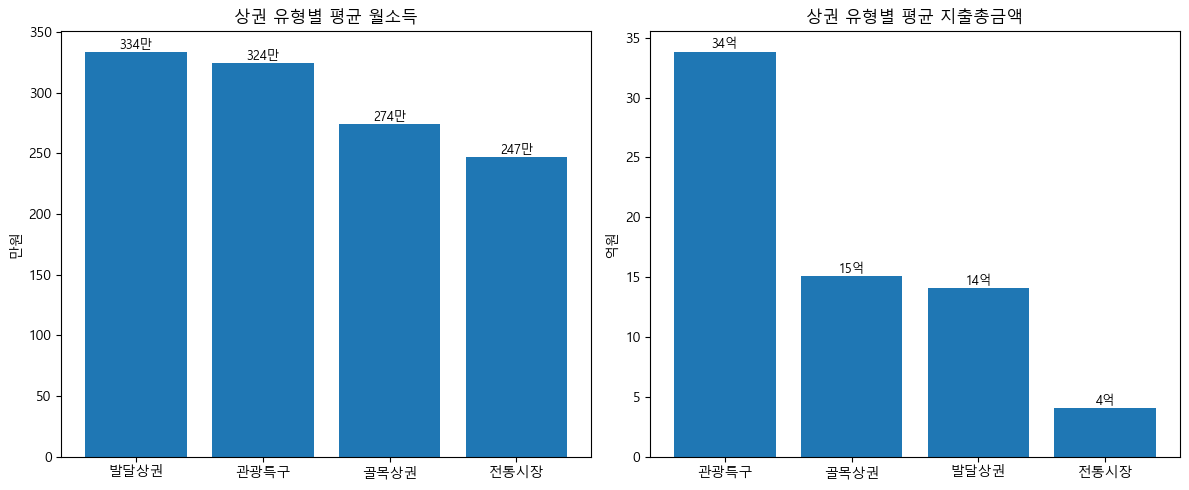

In [177]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── 유형별 평균 소득
소득_data = df_merge_clean.groupby('상권_구분_코드_명')['월평균소득'].mean().sort_values(ascending=False)
x1 = range(len(소득_data))
axes[0].bar(x1, 소득_data.values / 1e4)  # 만원 단위
axes[0].set_xticks(x1)
axes[0].set_xticklabels(소득_data.index)
axes[0].set_title('상권 유형별 평균 월소득')
axes[0].set_ylabel('만원')
for i, v in enumerate(소득_data.values):
    axes[0].text(i, v/1e4, f'{v/1e4:.0f}만', ha='center', va='bottom', fontsize=9)

# ── 유형별 평균 지출
지출_data = df_merge_clean.groupby('상권_구분_코드_명')['지출총금액'].mean().sort_values(ascending=False)
x2 = range(len(지출_data))
axes[1].bar(x2, 지출_data.values / 1e8)  # 억원 단위
axes[1].set_xticks(x2)
axes[1].set_xticklabels(지출_data.index)
axes[1].set_title('상권 유형별 평균 지출총금액')
axes[1].set_ylabel('억원')
for i, v in enumerate(지출_data.values):
    axes[1].text(i, v/1e8, f'{v/1e8:.0f}억', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [178]:
# 유형별 지출 항목 평균
지출_항목 = ['식료품지출', '의류신발지출', '생활용품지출', '의료비지출', 
             '교통지출', '여가지출', '문화지출', '교육지출', '유흥지출']

df_지출구성 = df_merge_clean.groupby('상권_구분_코드_명')[지출_항목].mean()
print(df_지출구성)

                   식료품지출        의류신발지출        생활용품지출         의료비지출  \
상권_구분_코드_명                                                           
골목상권        3.944991e+08  1.835010e+08  1.115060e+08  1.946179e+08   
관광특구        7.631189e+08  4.301220e+08  2.812447e+08  3.807943e+08   
발달상권        3.324924e+08  1.772383e+08  1.127982e+08  1.625147e+08   
전통시장        1.106240e+08  4.928076e+07  3.027712e+07  5.463268e+07   

                    교통지출          여가지출          문화지출          교육지출  \
상권_구분_코드_명                                                           
골목상권        2.457374e+08  5.679592e+07  4.674344e+07  2.092825e+08   
관광특구        5.889091e+08  1.737996e+08  9.912773e+07  5.276756e+08   
발달상권        2.377053e+08  6.262570e+07  4.359455e+07  2.177049e+08   
전통시장        6.448289e+07  1.547648e+07  1.276846e+07  5.247485e+07   

                    유흥지출  
상권_구분_코드_명                
골목상권        6.411560e+07  
관광특구        1.389832e+08  
발달상권        6.027990e+07  
전통시장        1.706769e+0

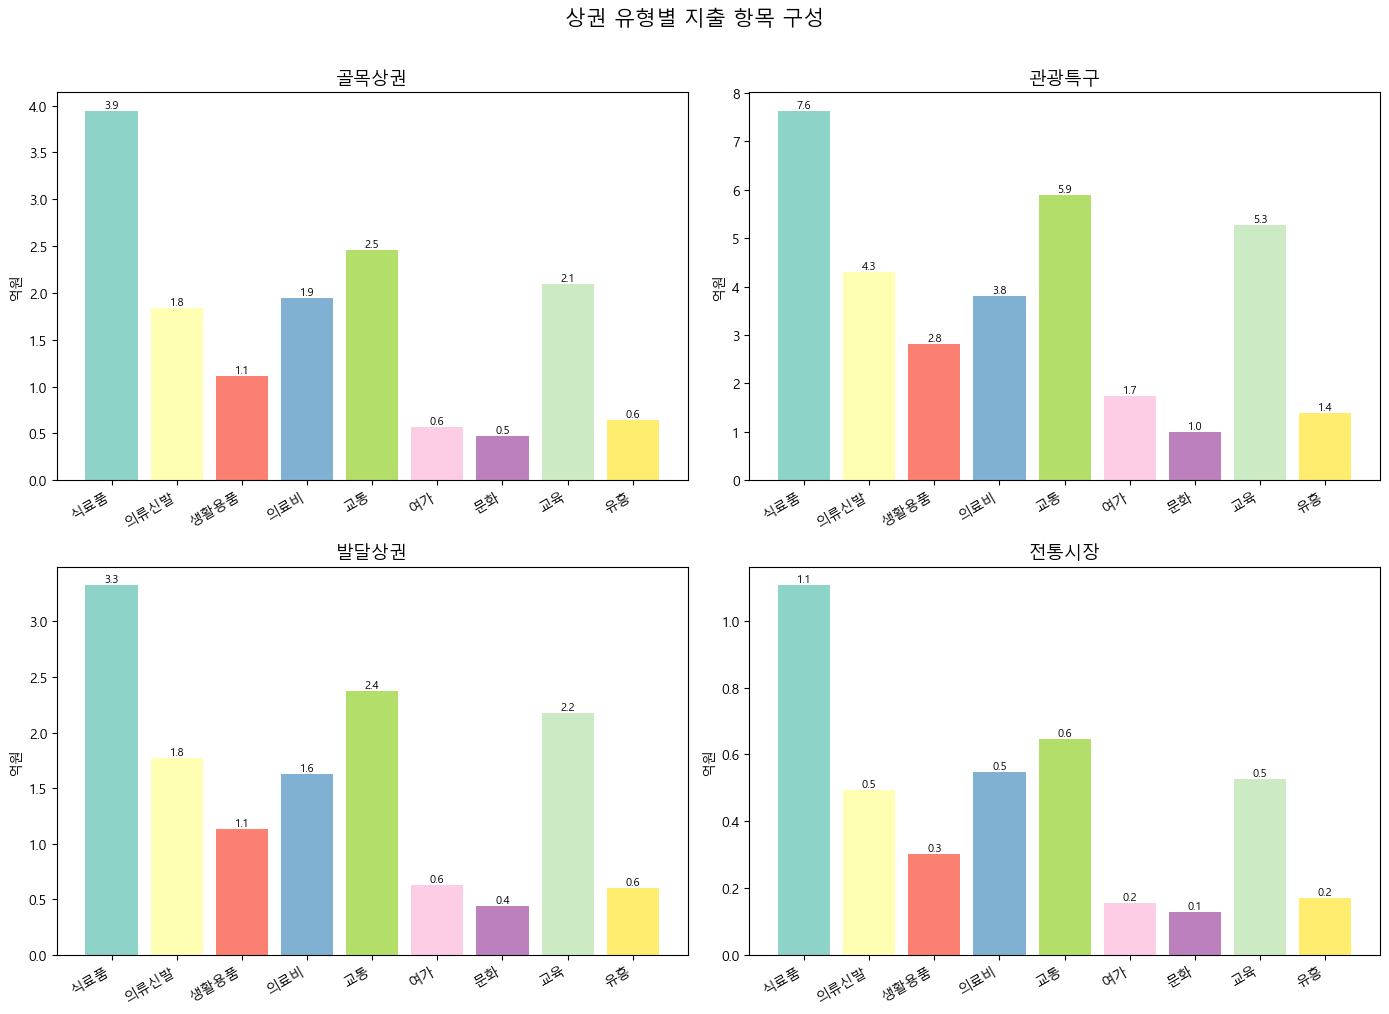


[ 지출 항목 비율 (%) ]
            식료품지출  의류신발지출  생활용품지출  의료비지출  교통지출  여가지출  문화지출  교육지출  유흥지출
상권_구분_코드_명                                                            
골목상권         26.2    12.2     7.4   12.9  16.3   3.8   3.1  13.9   4.3
관광특구         22.6    12.7     8.3   11.3  17.4   5.1   2.9  15.6   4.1
발달상권         23.6    12.6     8.0   11.6  16.9   4.5   3.1  15.5   4.3
전통시장         27.2    12.1     7.4   13.4  15.8   3.8   3.1  12.9   4.2


In [179]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

상권유형 = df_지출구성.index.tolist()
colors = plt.cm.Set3(np.linspace(0, 1, len(지출_항목)))

for i, 유형 in enumerate(상권유형):
    값 = df_지출구성.loc[유형] / 1e8  # 억원 단위
    bars = axes[i].bar(range(len(지출_항목)), 값, color=colors)
    axes[i].set_title(f'{유형}', fontsize=13)
    axes[i].set_xticks(range(len(지출_항목)))
    axes[i].set_xticklabels([c.replace('지출','') for c in 지출_항목], rotation=30, ha='right')
    axes[i].set_ylabel('억원')
    for j, v in enumerate(값):
        axes[i].text(j, v, f'{v:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('상권 유형별 지출 항목 구성', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# ── 비율로도 확인 (어떤 항목 비중이 높은지)
df_지출비율 = df_지출구성.div(df_지출구성.sum(axis=1), axis=0) * 100
print("\n[ 지출 항목 비율 (%) ]")
print(df_지출비율.round(1))

In [180]:
매출_항목 = ['당월_매출', '주중_매출', '주말_매출', '점심_매출', '저녁_매출', '심야_매출']

df_매출_연도별 = df_merge_clean.groupby('연도')[매출_항목].mean()
print(df_매출_연도별)

             당월_매출         주중_매출         주말_매출         점심_매출         저녁_매출  \
연도                                                                           
2020  4.473231e+10  3.398895e+10  1.074336e+10  1.119369e+10  1.238057e+10   
2021  5.168901e+10  3.907226e+10  1.261675e+10  1.361984e+10  1.443461e+10   
2022  5.445271e+10  4.107747e+10  1.337525e+10  1.408965e+10  1.509915e+10   
2023  5.730302e+10  4.331208e+10  1.399093e+10  1.482401e+10  1.567809e+10   
2024  5.774248e+10  4.380478e+10  1.393770e+10  1.507815e+10  1.555587e+10   
2025  5.766146e+10  4.354551e+10  1.411596e+10  1.514469e+10  1.536848e+10   

             심야_매출  
연도                  
2020  3.135866e+09  
2021  3.335675e+09  
2022  4.334832e+09  
2023  4.751762e+09  
2024  4.600087e+09  
2025  4.434118e+09  


In [181]:
print(df_merge_clean.groupby('연도')['상권_코드'].nunique())

연도
2020    1521
2021    1528
2022    1525
2023    1525
2024    1526
2025    1522
Name: 상권_코드, dtype: int64


In [182]:
# ── 성별 매출 비율
df_merge['남성_매출_비율'] = df_merge['남성_매출'] / df_merge['당월_매출'] * 100
df_merge['여성_매출_비율'] = df_merge['여성_매출'] / df_merge['당월_매출'] * 100

print("[ 상권 유형별 성별 매출 비율 ]")
print(df_merge.groupby('상권_구분_코드_명')[['남성_매출_비율', '여성_매출_비율']].mean().round(1))

# ── 연령대별 매출 비율
연령_매출_컬럼 = ['연령20_매출', '연령30_매출', '연령40_매출', '연령50_매출', '연령60이상_매출']

for col in 연령_매출_컬럼:
    df_merge[f'{col}_비율'] = df_merge[col] / df_merge['당월_매출'] * 100

연령_비율_컬럼 = [c + '_비율' for c in 연령_매출_컬럼]

print("\n[ 상권 유형별 연령대 매출 비율 ]")
print(df_merge.groupby('상권_구분_코드_명')[연령_비율_컬럼].mean().round(1))

[ 상권 유형별 성별 매출 비율 ]
            남성_매출_비율  여성_매출_비율
상권_구분_코드_명                    
골목상권            50.8      40.2
관광특구            42.6      46.9
발달상권            46.2      42.0
전통시장            45.3      48.0

[ 상권 유형별 연령대 매출 비율 ]
            연령20_매출_비율  연령30_매출_비율  연령40_매출_비율  연령50_매출_비율  연령60이상_매출_비율
상권_구분_코드_명                                                              
골목상권              10.2        16.8        22.5        22.1          19.0
관광특구              16.5        22.8        18.6        15.8          15.2
발달상권              12.2        18.7        21.6        19.4          15.7
전통시장               8.5        13.5        18.0        23.2          29.7


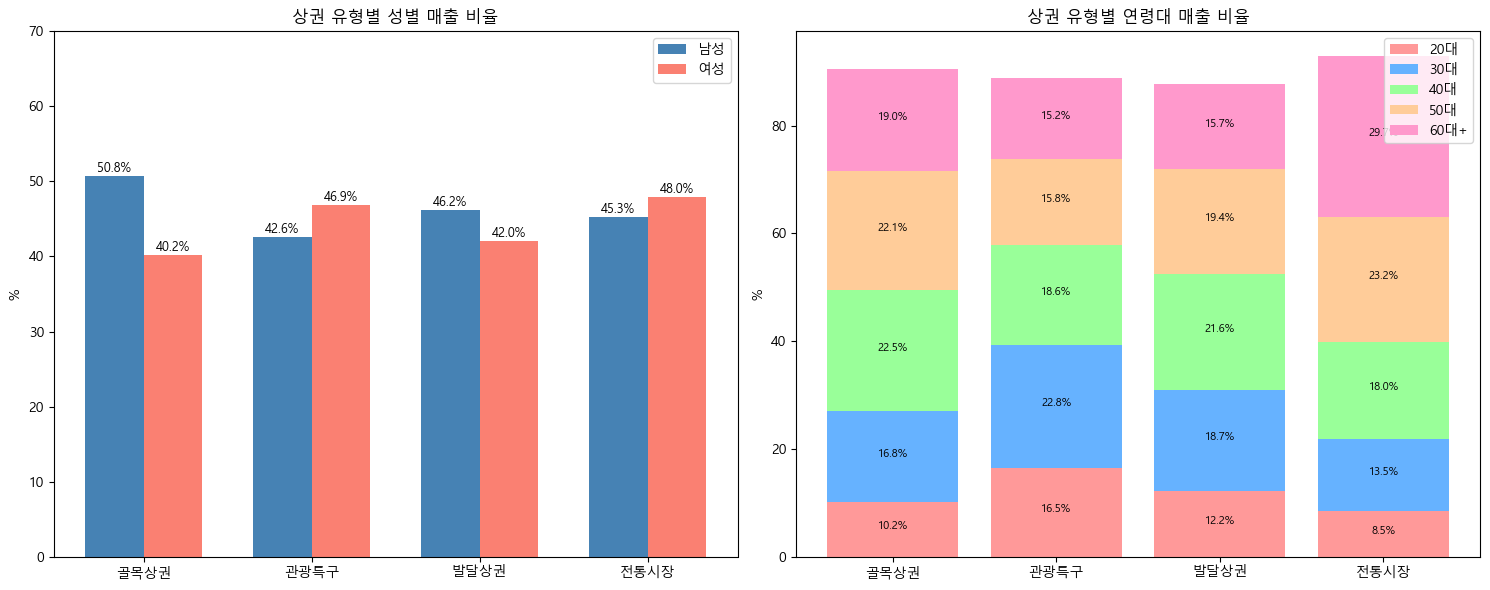

In [183]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── 성별 매출 비율
성별_data = df_merge.groupby('상권_구분_코드_명')[['남성_매출_비율', '여성_매출_비율']].mean()
x = range(len(성별_data))
width = 0.35

axes[0].bar([i - width/2 for i in x], 성별_data['남성_매출_비율'], width, label='남성', color='steelblue')
axes[0].bar([i + width/2 for i in x], 성별_data['여성_매출_비율'], width, label='여성', color='salmon')
axes[0].set_xticks(x)
axes[0].set_xticklabels(성별_data.index)
axes[0].set_ylabel('%')
axes[0].set_title('상권 유형별 성별 매출 비율')
axes[0].legend()
axes[0].set_ylim(0, 70)
for i, (m, f) in enumerate(zip(성별_data['남성_매출_비율'], 성별_data['여성_매출_비율'])):
    axes[0].text(i - width/2, m + 0.5, f'{m:.1f}%', ha='center', fontsize=9)
    axes[0].text(i + width/2, f + 0.5, f'{f:.1f}%', ha='center', fontsize=9)

# ── 연령대별 매출 비율 (누적 막대)
연령_data = df_merge.groupby('상권_구분_코드_명')[연령_비율_컬럼].mean()
연령_labels = ['20대', '30대', '40대', '50대', '60대+']
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']

bottom = [0] * len(연령_data)
for i, (col, label, color) in enumerate(zip(연령_비율_컬럼, 연령_labels, colors)):
    values = 연령_data[col].values
    axes[1].bar(range(len(연령_data)), values, bottom=bottom, label=label, color=color)
    for j, (v, b) in enumerate(zip(values, bottom)):
        if v > 3:
            axes[1].text(j, b + v/2, f'{v:.1f}%', ha='center', fontsize=8)
    bottom = [b + v for b, v in zip(bottom, values)]

axes[1].set_xticks(range(len(연령_data)))
axes[1].set_xticklabels(연령_data.index)
axes[1].set_ylabel('%')
axes[1].set_title('상권 유형별 연령대 매출 비율')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [184]:
# 여성 매출 비율 상위/하위 상권의 지출 구성 비교
상위_여성 = df_merge.nlargest(200, '여성_매출_비율')
하위_여성 = df_merge.nsmallest(200, '여성_매출_비율')  # 남성 비율 높은 상권

print("[ 여성 매출 높은 상권 평균 지출 구성 ]")
print((상위_여성[지출_항목].mean() / 1e8).round(2))

print("\n[ 남성 매출 높은 상권 평균 지출 구성 ]")
print((하위_여성[지출_항목].mean() / 1e8).round(2))

[ 여성 매출 높은 상권 평균 지출 구성 ]
식료품지출     1.54
의류신발지출    0.74
생활용품지출    0.45
의료비지출     0.76
교통지출      1.00
여가지출      0.24
문화지출      0.19
교육지출      0.84
유흥지출      0.26
dtype: float64

[ 남성 매출 높은 상권 평균 지출 구성 ]
식료품지출     1.77
의류신발지출    0.84
생활용품지출    0.52
의료비지출     0.86
교통지출      1.11
여가지출      0.27
문화지출      0.21
교육지출      0.95
유흥지출      0.29
dtype: float64


        여성 매출 높은 상권  남성 매출 높은 상권
식료품지출          25.6         25.9
의류신발지출         12.3         12.3
생활용품지출          7.5          7.6
의료비지출          12.7         12.6
교통지출           16.5         16.3
여가지출            4.0          3.9
문화지출            3.1          3.1
교육지출           14.0         13.9
유흥지출            4.3          4.3


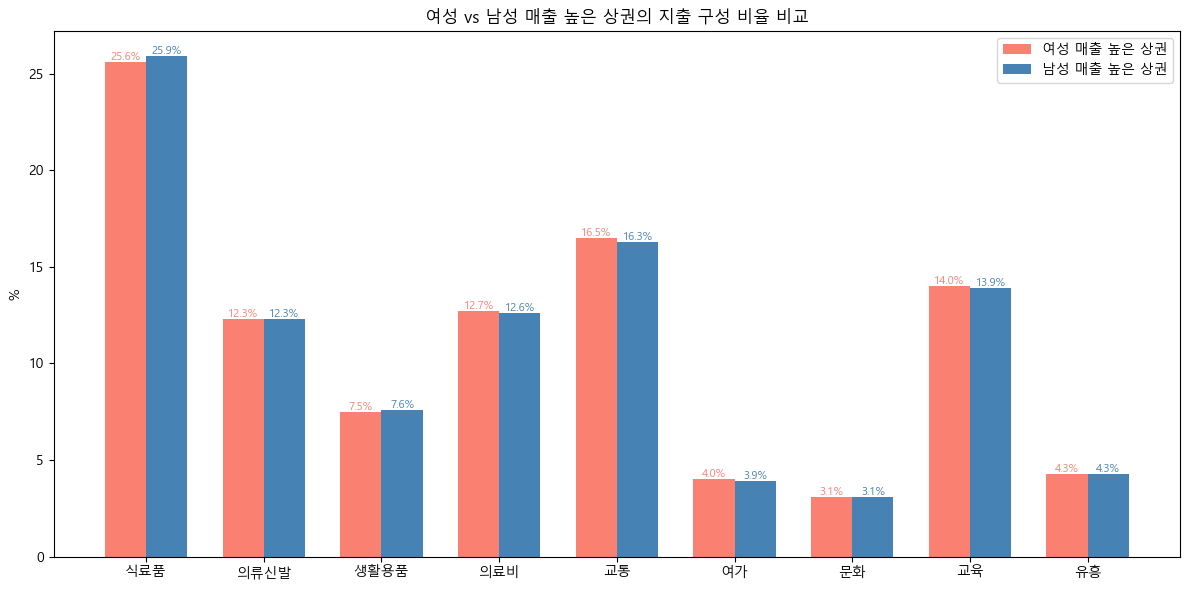

In [185]:
# 절대값 말고 비율로 비교
여성_합계 = 상위_여성[지출_항목].mean().sum()
남성_합계 = 하위_여성[지출_항목].mean().sum()

여성_비율 = (상위_여성[지출_항목].mean() / 여성_합계 * 100).round(1)
남성_비율 = (하위_여성[지출_항목].mean() / 남성_합계 * 100).round(1)

비교_df = pd.DataFrame({
    '여성 매출 높은 상권': 여성_비율,
    '남성 매출 높은 상권': 남성_비율
})
print(비교_df)

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(지출_항목))
width = 0.35
labels = [c.replace('지출','') for c in 지출_항목]

bars1 = ax.bar([i - width/2 for i in x], 여성_비율, width, label='여성 매출 높은 상권', color='salmon')
bars2 = ax.bar([i + width/2 for i in x], 남성_비율, width, label='남성 매출 높은 상권', color='steelblue')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('%')
ax.set_title('여성 vs 남성 매출 높은 상권의 지출 구성 비율 비교')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, color='salmon')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=8, color='steelblue')

plt.tight_layout()
plt.show()

In [186]:
# 연령대별 매출 비율 계산
연령_매출_컬럼 = ['연령20_매출', '연령30_매출', '연령40_매출', '연령50_매출', '연령60이상_매출']

for col in 연령_매출_컬럼:
    df_merge[f'{col}_비율'] = df_merge[col] / df_merge['당월_매출'] * 100

연령_비율_컬럼 = [c + '_비율' for c in 연령_매출_컬럼]

# 상권 유형별 연령대 매출 비율
연령_data = df_merge.groupby('상권_구분_코드_명')[연령_비율_컬럼].mean()
연령_data.columns = ['20대', '30대', '40대', '50대', '60대+']
print(연령_data.round(1))

             20대   30대   40대   50대  60대+
상권_구분_코드_명                              
골목상권        10.2  16.8  22.5  22.1  19.0
관광특구        16.5  22.8  18.6  15.8  15.2
발달상권        12.2  18.7  21.6  19.4  15.7
전통시장         8.5  13.5  18.0  23.2  29.7


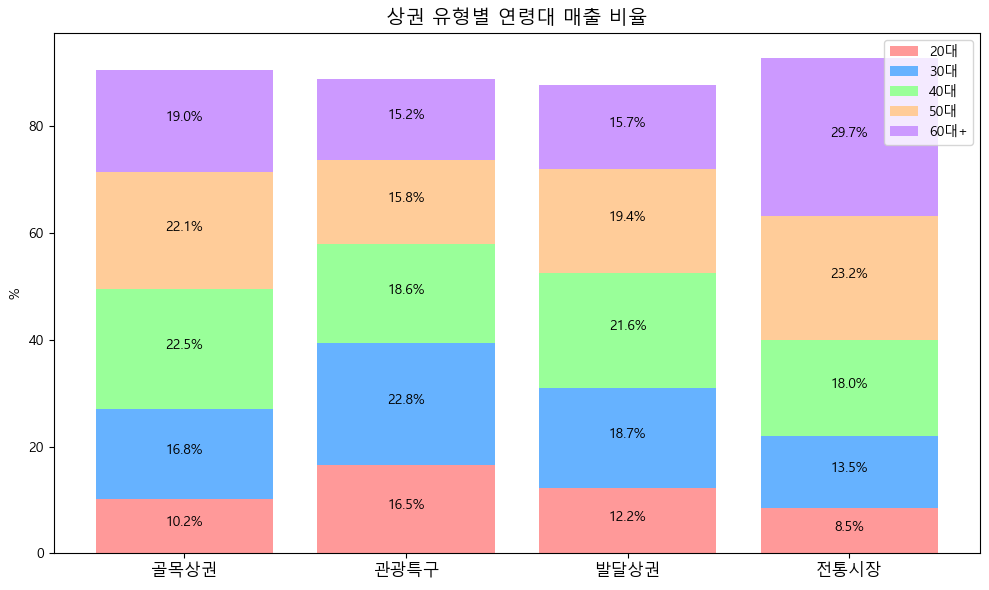

In [187]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#CC99FF']
bottom = [0] * len(연령_data)

for col, color in zip(연령_data.columns, colors):
    values = 연령_data[col].values
    ax.bar(range(len(연령_data)), values, bottom=bottom, label=col, color=color)
    for j, (v, b) in enumerate(zip(values, bottom)):
        if v > 3:
            ax.text(j, b + v/2, f'{v:.1f}%', ha='center', fontsize=10)
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_xticks(range(len(연령_data)))
ax.set_xticklabels(연령_data.index, fontsize=12)
ax.set_ylabel('%')
ax.set_title('상권 유형별 연령대 매출 비율', fontsize=14)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [190]:
# 시간대별 매출 비율 계산
시간_매출_컬럼 = ['새벽_매출', '오전_매출','점심_매출', '오후_매출','저녁_매출', '심야_매출', '주중_매출', '주말_매출']

for col in 시간_매출_컬럼:
    df_merge[f'{col}_비율'] = df_merge[col] / df_merge['당월_매출'] * 100

시간_비율_컬럼 = [c + '_비율' for c in 시간_매출_컬럼]

# 상권 유형별 평균
시간_data = df_merge.groupby('상권_구분_코드_명')[시간_비율_컬럼].mean()
시간_data.columns = ['새벽', '오전', '점심', '오후','저녁', '심야', '주중', '주말']
print(시간_data.round(1))

             새벽    오전    점심    오후    저녁    심야    주중    주말
상권_구분_코드_명                                               
골목상권        3.0   8.9  24.2  21.5  32.0  10.3  75.5  24.5
관광특구        4.0   7.2  25.1  26.9  28.2   8.7  70.8  29.2
발달상권        2.6  10.2  27.1  23.4  28.0   8.6  78.4  21.6
전통시장        2.2  10.3  24.6  25.1  30.2   7.5  74.1  25.9


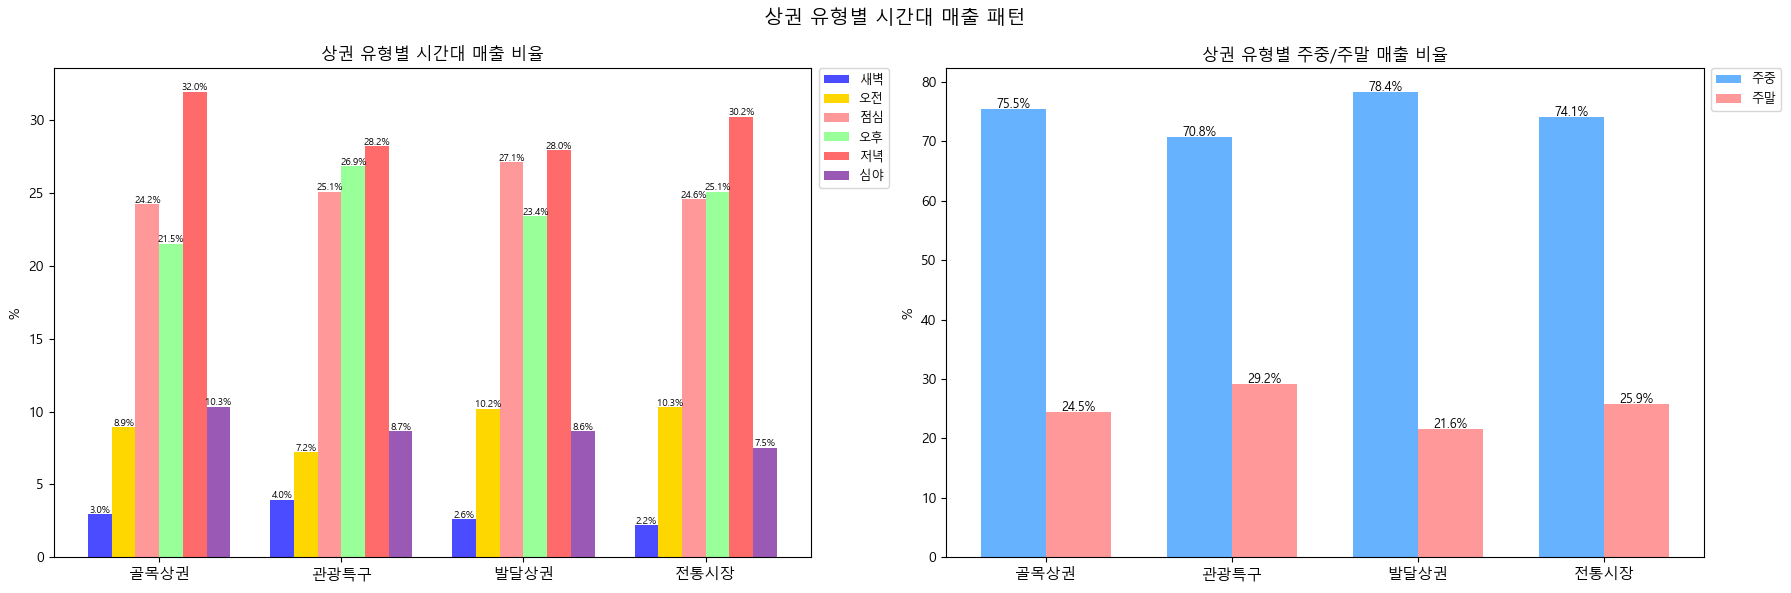

In [194]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

시간대_cols = ['새벽', '오전', '점심', '오후', '저녁', '심야']
주중주말_cols = ['주중', '주말']

# ── 시간대별
시간대_data = 시간_data[시간대_cols]
x = range(len(시간대_data))
width = 0.13
colors_시간 = ['#4B4BFF', '#FFD700', '#FF9999', '#99FF99', '#FF6B6B', '#9B59B6']

for i, (col, color) in enumerate(zip(시간대_cols, colors_시간)):
    bars = axes[0].bar([j + i*width for j in x], 시간대_data[col], width, label=col, color=color)
    for bar in bars:
        h = bar.get_height()
        if h > 2:
            axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.1,
                        f'{h:.1f}%', ha='center', fontsize=7)

axes[0].set_xticks([j + width*2.5 for j in x])
axes[0].set_xticklabels(시간대_data.index, fontsize=11)
axes[0].set_ylabel('%')
axes[0].set_title('상권 유형별 시간대 매출 비율')

# ✅ 범례를 그래프 오른쪽 바깥으로
axes[0].legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=9)

# ── 주중/주말
주중주말_data = 시간_data[주중주말_cols]
width2 = 0.35
colors_주 = ['#66B2FF', '#FF9999']

for i, (col, color) in enumerate(zip(주중주말_cols, colors_주)):
    bars = axes[1].bar([j + i*width2 for j in x], 주중주말_data[col], width2, label=col, color=color)
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{bar.get_height():.1f}%', ha='center', fontsize=9)

axes[1].set_xticks([j + width2/2 for j in x])
axes[1].set_xticklabels(주중주말_data.index, fontsize=11)
axes[1].set_ylabel('%')
axes[1].set_title('상권 유형별 주중/주말 매출 비율')
axes[1].legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=9)

plt.suptitle('상권 유형별 시간대 매출 패턴', fontsize=14)
plt.tight_layout()
plt.show()